In [ ]:
# 1. Heart Disease Prediction Using MLP

  # a) Check the dataset for missing values and handle, if any.

  # b) Display input and output features of the dataset.

  # c) Encode non-numeric input attributes using Label Encoder.

  # d) Construct an MLP with configuration 11x128x64x32x1. Use Adam optimizer and appropriate activation functions and train the model.

  # Predict heart disease for test data and display confusion matrix, accuracy, recall, precision and F1-score.


In [ ]:
# a) Check the dataset for missing values and handle, if any.

# Getting the CSV file from the drive
from google.colab import drive
drive.mount('/content/drive')

# # Verify the mount was successful
# !ls '/content/drive/My Drive'


Mounted at /content/drive


In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
## For Encoding
# from sklearn.preprocessing import LabelEncoder

# Update this path to match where your file is in your Drive
file_path = '/content/drive/My Drive/Colab Notebooks/Yujan_NN/NN_Lab3/heart.csv'

# Read the CSV
df = pd.read_csv(file_path)

# Display the first few rows
# print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop rows with any missing values
df = df.dropna()

# # Checking to confirm the dropping of missing values
# # Check for missing values
# print("\nMissing Values:")
# print(df.isnull().sum())


Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# b) Display input and output features of the dataset.

## What are we going to do?
  # See all the column names
  # Separate input features(X) and output label(Y)
  # Print them Clearly

# Show all column names
print("All Columns in Dataset:")
print(df.columns.tolist())

# Output feature (the thing we want to predict)
output_feature = 'HeartDisease'

# Input features (everything except the output)
input_features = df.drop(columns=[output_feature]).columns.tolist()

print("\nInput Features:")
for col in input_features:
    print("-", col)

print("\nOutput Feature:")
print(output_feature)


# # Shuffle data just prep for next
# df = df.sample(frac=1).reset_index(drop=True)

All Columns in Dataset:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Input Features:
- Age
- Sex
- ChestPainType
- RestingBP
- Cholesterol
- FastingBS
- RestingECG
- MaxHR
- ExerciseAngina
- Oldpeak
- ST_Slope

Output Feature:
HeartDisease


In [ ]:
# c) Encode non-numeric input attributes using Label Encoder.

from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying original DataFrame
df_encoded = df.copy()

# Encode non-numeric input attributes using Label Encoder.
# The 5 non-numeric attributes present in the dataset
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Create an empty dictionary to store LabelEncoder objects for each column
# (This helps reuse the same encoding later if new data comes in)
label_encoders = {}

for col in categorical_cols:

    # Initialize a LabelEncoder for the current column
    le = LabelEncoder()

    # Fit the encoder to the column's unique values and transform the column
    # Example: If 'Sex' has 'Male' and 'Female', it may convert them to 1 and 0
    df_encoded[col] = le.fit_transform(df[col])

    # Store the encoder in the dictionary for future use
    label_encoders[col] = le


# Print the DataFrame after encoding
print("Scaled Input variable:\n", df_encoded)


Scaled Input variable:
      Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0     40    1              1        140          289          0           1   
1     49    0              2        160          180          0           1   
2     37    1              1        130          283          0           2   
3     48    0              0        138          214          0           1   
4     54    1              2        150          195          0           1   
..   ...  ...            ...        ...          ...        ...         ...   
913   45    1              3        110          264          0           1   
914   68    1              0        144          193          1           1   
915   57    1              0        130          131          0           1   
916   57    0              1        130          236          0           0   
917   38    1              2        138          175          0           1   

     MaxHR  ExerciseAngina 

In [ ]:

# d) Construct an MLP with configuration 11x128x64x32x1. Use Adam optimizer and appropriate activation functions and train the model.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Split data into features (X) and target (y)
X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scale the features
# Scaling is done after to avoid overfitting?
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Build the MLP model
model = Sequential()

## Add layers to the MLP
# Input layer + 1st hidden layer with 128 neurons and ReLU
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# 2nd hidden layer with 64 neurons
model.add(Dense(64, activation='relu'))

# 3rd hidden layer with 32 neurons
model.add(Dense(32, activation='relu'))

# Output layer with 1 neuron and sigmoid activation (binary output: 0 or 1)
model.add(Dense(1, activation='sigmoid'))

##  Compile the model
model.compile(
    optimizer=Adam(),                    # Optimizer: Adam
    loss='binary_crossentropy',         # Loss function: for binary classification
    metrics=['accuracy']                # Evaluation metric
)

## Show model summary
model.summary()

## Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6935 - loss: 0.6119 - val_accuracy: 0.8152 - val_loss: 0.4387
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8638 - loss: 0.3547 - val_accuracy: 0.8370 - val_loss: 0.3975
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8451 - loss: 0.3738 - val_accuracy: 0.8533 - val_loss: 0.3748
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8677 - loss: 0.3294 - val_accuracy: 0.8478 - val_loss: 0.3841
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8862 - loss: 0.2920 - val_accuracy: 0.8641 - val_loss: 0.3527
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8930 - loss: 0.2696 - val_accuracy: 0.8641 - val_loss: 0.3390
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8906 - loss: 0.2627 - val_accuracy: 0.8207 - val_loss: 0.3943
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8832 - loss: 0.2541 - val_accuracy: 0.8587 - val_loss

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


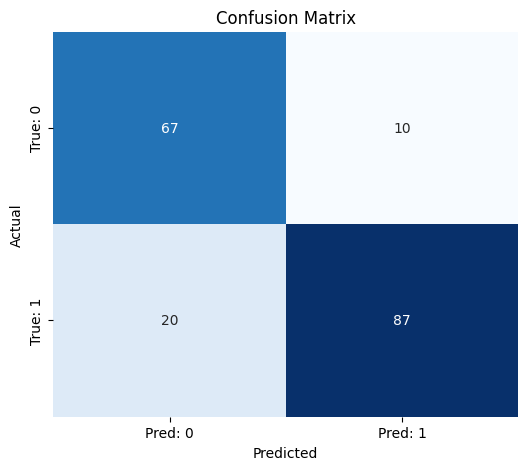


Accuracy:  0.8370
Precision: 0.8969
Recall:    0.8131
F1 Score:  0.8529

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        77
           1       0.90      0.81      0.85       107

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [ ]:
import matplotlib.pyplot as plt # For plotting graph
import seaborn as sns           # For better-looking visualizations
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score # For model evaluation

# Predict probabilities on the test data
y_pred_prob = model.predict(X_test_scaled)


# Convert probabilities to class labels (0 or 1) and flatten to 1D array
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Pred: 0', 'Pred: 1'], yticklabels=['True: 0', 'True: 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate and display individual evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nAccuracy:  {accuracy:.4f}") # (TP + TN) / Total
print(f"Precision: {precision:.4f}")  # TP / (TP + FP)
print(f"Recall:    {recall:.4f}")     # TP / (TP + FN)
print(f"F1 Score:  {f1:.4f}")         # Harmonic mean of precision & recall [F1=2×((Precision+Recal)/(Precision+Recall​))]

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
